# Évaluation des modèles XGBoost — District de Foumban (2023–2025)

**Cible régresseur :** `log_incidence = log1p(cas / p_totale × 1000)`  
**Cible classifieur :** `high = (incidence_rate > seuil_75e_pct_régional)`  
**Vérité terrain :** *Cas de paludisme confirmés FOSA et Communauté* (PNLP)  
**Population Foumban :** 257 429 habitants (district_static.csv)


## 0. Imports & configuration

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)

# ── Chemins ──────────────────────────────────────────────────────────────────
PATH_CLIMATE    = "cameroon_climate_foumban_2022_2026.csv"
PATH_STATIC     = "district_static.csv"
PATH_PNLP       = "Données PNLP 2023_2024_2025 - ok.xls"
PATH_REGRESSOR  = "final_regressor.joblib"
PATH_CLASSIFIER = "final_classifier.joblib"

# ── Style matplotlib ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
BLUE, ORANGE, GREEN, RED = "#378ADD", "#D85A30", "#639922", "#E24B4A"
THRESHOLD = 9.398569   # seuil 75e pct Foumban (district_static)

print("Imports OK")


Imports OK


## 1. Chargement & préparation des données

In [6]:
# ── 1.1 Données climatiques ─────────────────────────────────────────────────
clim = pd.read_csv(PATH_CLIMATE, parse_dates=["Date"])
clim = clim.rename(columns={"Humidity_%": "Humidity_pct"})
clim = clim.sort_values("Date").reset_index(drop=True)
clim["year"]  = clim["Date"].dt.year
clim["month"] = clim["Date"].dt.month

monthly = clim.groupby(["year", "month"]).agg(
    Temperature_C    = ("Temperature_C",    "mean"),
    Humidity_pct     = ("Humidity_pct",     "mean"),
    Pressure_hPa     = ("Pressure_hPa",     "mean"),
    Precipitation_mm = ("Precipitation_mm", "sum"),
).reset_index().sort_values(["year", "month"]).reset_index(drop=True)

monthly["sin_month"] = np.sin(2 * np.pi * monthly["month"] / 12)
monthly["cos_month"] = np.cos(2 * np.pi * monthly["month"] / 12)
for lag in [1, 2]:
    monthly[f"Temperature_C_lag{lag}"]    = monthly["Temperature_C"].shift(lag)
    monthly[f"Precipitation_mm_lag{lag}"] = monthly["Precipitation_mm"].shift(lag)
    monthly[f"Humidity_pct_lag{lag}"]     = monthly["Humidity_pct"].shift(lag)

print(f"Climatique mensuel : {monthly.shape} | plage : {monthly.year.min()}–{monthly.year.max()}")
monthly.head(4)


Climatique mensuel : (41, 14) | plage : 2022–2026


,year,month,Temperature_C,Humidity_pct,Pressure_hPa,Precipitation_mm,sin_month,cos_month,Temperature_C_lag1,Precipitation_mm_lag1,Humidity_pct_lag1,Temperature_C_lag2,Precipitation_mm_lag2,Humidity_pct_lag2
0,2022,9,20.257667,86.791333,888.038667,206.7,-1.000000e+00,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,10,20.890323,82.832258,887.932581,234.6,-8.660254e-01,5.000000e-01,20.257667,206.7,86.791333,NaN,NaN,NaN
2,2022,11,22.285667,61.355667,887.196667,8.9,-5.000000e-01,8.660254e-01,20.890323,234.6,82.832258,20.257667,206.7,86.791333
3,2022,12,22.688065,48.220323,887.146774,0.5,-2.449294e-16,1.000000e+00,22.285667,8.9,61.355667,20.890323,234.6,82.832258


In [7]:
# ── 1.2 Données statiques district ──────────────────────────────────────────
stat    = pd.read_csv(PATH_STATIC)
foumban = stat[stat["district"] == "Foumban"].iloc[0]
print("=== Foumban — variables statiques ===")
print(foumban[["district","region","SHP_lat","SHP_lon","SHP_Area","cluster","p_totale","threshold_75"]].to_string())


=== Foumban — variables statiques ===
district            Foumban
region                Ouest
SHP_lat           10.867908
SHP_lon            5.705388
SHP_Area        1468.806712
cluster                   1
p_totale             257429
threshold_75       9.398569


In [8]:
# ── 1.3 Vérité terrain PNLP ─────────────────────────────────────────────────
rows = []
for yr in [2023, 2024, 2025]:
    df_yr = pd.read_excel(PATH_PNLP, engine="xlrd", sheet_name=str(yr), header=None)
    for m_idx in range(12):
        rows.append({
            "year":  yr,
            "month": m_idx + 1,
            "cases_confirmed": df_yr.iloc[7, m_idx + 1],   # ligne 7 = FOSA + Communauté
        })

pnlp = pd.DataFrame(rows)
print(f"PNLP : {len(pnlp)} mois — indicateur : 'Cas de paludisme confirmés FOSA et Communauté'")
pnlp


PNLP : 36 mois — indicateur : 'Cas de paludisme confirmés FOSA et Communauté'


,year,month,cases_confirmed
0,2023,1,2185
1,2023,2,1774
2,2023,3,2346
3,2023,4,2456
4,2023,5,2488
5,2023,6,2185
6,2023,7,2308
7,2023,8,2033
8,2023,9,1749
9,2023,10,1897


In [9]:
# ── 1.4 Fusion & calcul des cibles ──────────────────────────────────────────
FEATURES = [
    "sin_month", "cos_month",
    "SHP_lat", "SHP_lon", "SHP_Area", "cluster",
    "Temperature_C", "Humidity_pct", "Pressure_hPa", "Precipitation_mm",
    "Temperature_C_lag1", "Temperature_C_lag2",
    "Precipitation_mm_lag1", "Precipitation_mm_lag2",
    "Humidity_pct_lag1", "Humidity_pct_lag2",
]

merged = monthly.merge(pnlp, on=["year", "month"], how="left")
merged["SHP_lat"]      = foumban["SHP_lat"]
merged["SHP_lon"]      = foumban["SHP_lon"]
merged["SHP_Area"]     = foumban["SHP_Area"]
merged["cluster"]      = foumban["cluster"]
merged["p_totale"]     = foumban["p_totale"]
merged["threshold_75"] = foumban["threshold_75"]

merged["incidence_rate"] = merged["cases_confirmed"] / merged["p_totale"] * 1000
merged["log_incidence"]  = np.log1p(merged["incidence_rate"])
merged["high"]           = (merged["incidence_rate"] > foumban["threshold_75"]).astype(int)

# Fenêtre d'évaluation : 2023–2025, lags valides
eval_df = merged[
    merged["year"].isin([2023, 2024, 2025]) &
    merged[["Temperature_C_lag1", "Temperature_C_lag2"]].notna().all(axis=1)
].copy().reset_index(drop=True)

print(f"Ensemble d'évaluation : {len(eval_df)} mois")
print(f"  Mois 'high' : {eval_df['high'].sum()} / {len(eval_df)}")
print(f"  Incidence réelle — min {eval_df['incidence_rate'].min():.2f}  "
      f"moy {eval_df['incidence_rate'].mean():.2f}  max {eval_df['incidence_rate'].max():.2f}")


Ensemble d'évaluation : 36 mois
  Mois 'high' : 4 / 36
  Incidence réelle — min 4.83  moy 7.59  max 10.67


## 2. Chargement des modèles

In [10]:
reg = joblib.load(PATH_REGRESSOR)
clf = joblib.load(PATH_CLASSIFIER)
print("Régresseur  :", type(reg).__name__)
print("Classifieur :", type(clf).__name__)
print("\nHyperparamètres régresseur :")
for k, v in reg.get_params().items():
    if k in ["n_estimators","max_depth","learning_rate","subsample","colsample_bytree"]:
        print(f"  {k:20s}: {v}")


Régresseur  : XGBRegressor
Classifieur : XGBClassifier

Hyperparamètres régresseur :
  colsample_bytree    : 0.8165253555750989
  learning_rate       : 0.062039098471647035
  max_depth           : 5
  n_estimators        : 500
  subsample           : 0.715068312794609


## 3. Prédictions

In [11]:
X = eval_df[FEATURES]

# Régresseur
eval_df["pred_log_inc"]   = reg.predict(X)
eval_df["pred_incidence"] = np.expm1(eval_df["pred_log_inc"])

# Classifieur
eval_df["pred_class"] = clf.predict(X)
eval_df["pred_proba"] = clf.predict_proba(X)[:, 1]

# Erreur relative
eval_df["error_pct"] = (
    (eval_df["pred_incidence"] - eval_df["incidence_rate"])
    / eval_df["incidence_rate"] * 100
)

mois_fr = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
eval_df["label"] = eval_df.apply(lambda r: f"{mois_fr[int(r.month)-1]} {int(r.year)}", axis=1)

cols_show = ["label","cases_confirmed","incidence_rate","pred_incidence",
             "error_pct","high","pred_class","pred_proba"]
eval_df[cols_show].style.format({
    "incidence_rate": "{:.3f}", "pred_incidence": "{:.3f}",
    "error_pct": "{:+.1f}%", "pred_proba": "{:.2f}",
}).background_gradient(subset=["error_pct"], cmap="RdYlGn_r", vmin=-50, vmax=80)


,label,cases_confirmed,incidence_rate,pred_incidence,error_pct,high,pred_class,pred_proba
0,Jan 2023,2185.000000,8.488,0.797,-90.6%,0,0,0.34
1,Fév 2023,1774.000000,6.891,0.826,-88.0%,0,1,0.65
2,Mar 2023,2346.000000,9.113,1.046,-88.5%,0,1,0.64
3,Avr 2023,2456.000000,9.540,2.292,-76.0%,1,1,0.98
4,Mai 2023,2488.000000,9.665,1.895,-80.4%,1,1,0.94
5,Jun 2023,2185.000000,8.488,1.839,-78.3%,0,1,0.97
6,Jul 2023,2308.000000,8.966,1.557,-82.6%,0,1,0.82
7,Aoû 2023,2033.000000,7.897,0.896,-88.7%,0,0,0.42
8,Sep 2023,1749.000000,6.794,0.736,-89.2%,0,0,0.48
9,Oct 2023,1897.000000,7.369,0.686,-90.7%,0,0,0.38


## 4. Métriques globales

In [ ]:
y_log  = eval_df["log_incidence"]
y_inc  = eval_df["incidence_rate"]
y_high = eval_df["high"]

p_log  = eval_df["pred_log_inc"]
p_inc  = eval_df["pred_incidence"]
p_cls  = eval_df["pred_class"]
p_prb  = eval_df["pred_proba"]

# ── Régression ───────────────────────────────────────────────────────────────
r2       = r2_score(y_log,  p_log)
rmse_log = np.sqrt(mean_squared_error(y_log, p_log))
mae_log  = mean_absolute_error(y_log, p_log)
rmse_inc = np.sqrt(mean_squared_error(y_inc, p_inc))
mae_inc  = mean_absolute_error(y_inc, p_inc)
mape     = np.mean(np.abs((y_inc - p_inc) / y_inc)) * 100
bias_pct = (p_inc.mean() / y_inc.mean() - 1) * 100

# ── Classification ───────────────────────────────────────────────────────────
f1   = f1_score(y_high, p_cls, zero_division=0)
prec = precision_score(y_high, p_cls, zero_division=0)
rec  = recall_score(y_high, p_cls, zero_division=0)
try:
    auc = roc_auc_score(y_high, p_prb)
except:
    auc = float("nan")

print("=" * 52)
print("  RÉGRESSION — log-incidence")
print("=" * 52)
print(f"  R²           : {r2:+.4f}   (réf. TimeSeries : +0.628)")
print(f"  RMSE (log)   : {rmse_log:.4f}")
print(f"  MAE  (log)   : {mae_log:.4f}")
print()
print("  RÉGRESSION — incidence / 1000 hab.")
print(f"  RMSE         : {rmse_inc:.4f}")
print(f"  MAE          : {mae_inc:.4f}")
print(f"  MAPE         : {mape:.2f}%")
print(f"  Biais moyen  : {bias_pct:+.1f}%  ({y_inc.mean():.3f} réelle → {p_inc.mean():.3f} prédite)")
print()
print("=" * 52)
print("  CLASSIFICATION — high (incidence > 75e pct)")
print("=" * 52)
print(f"  F1-score     : {f1:.4f}   (réf. TimeSeries : 0.655)")
print(f"  Precision    : {prec:.4f}")
print(f"  Recall       : {rec:.4f}")
print(f"  ROC-AUC      : {auc:.4f}")
print()
print(classification_report(y_high, p_cls, target_names=["Normal","High"], zero_division=0))


  RÉGRESSION — log-incidence
  R²           : -68.6463   (réf. TimeSeries : +0.628)
  RMSE (log)   : 1.4176
  MAE  (log)   : 1.4053

  RÉGRESSION — incidence / 1000 hab.
  RMSE         : 6.5681
  MAE          : 6.4588
  MAPE         : 85.29%
  Biais moyen  : -85.1%  (7.593 réelle → 1.134 prédite)

  CLASSIFICATION — high (incidence > 75e pct)
  F1-score     : 0.2500   (réf. TimeSeries : 0.655)
  Precision    : 0.1500
  Recall       : 0.7500
  ROC-AUC      : 0.6641

              precision    recall  f1-score   support

      Normal       0.94      0.47      0.62        32
        High       0.15      0.75      0.25         4

    accuracy                           0.50        36
   macro avg       0.54      0.61      0.44        36
weighted avg       0.85      0.50      0.58        36



In [13]:
# ── Par année ────────────────────────────────────────────────────────────────
print(f"{'Année':>6} {'R² (log)':>10} {'MAPE':>8} {'F1':>6} {'TP/réels':>10}")
print("-" * 46)
for yr in [2023, 2024, 2025]:
    s = eval_df[eval_df["year"] == yr]
    r2_yr   = r2_score(s["log_incidence"], s["pred_log_inc"])
    mape_yr = np.mean(np.abs((s["incidence_rate"] - s["pred_incidence"]) / s["incidence_rate"])) * 100
    f1_yr   = f1_score(s["high"], s["pred_class"], zero_division=0)
    tp = int((s["high"] == 1) & (s["pred_class"] == 1)).sum()
    n_high = int(s["high"].sum())
    print(f"{yr:>6} {r2_yr:>10.3f} {mape_yr:>7.1f}% {f1_yr:>6.3f}  {tp}/{n_high}")


 Année   R² (log)     MAPE     F1   TP/réels
----------------------------------------------


TypeError: cannot convert the series to <class 'int'>

## 5. Visualisations

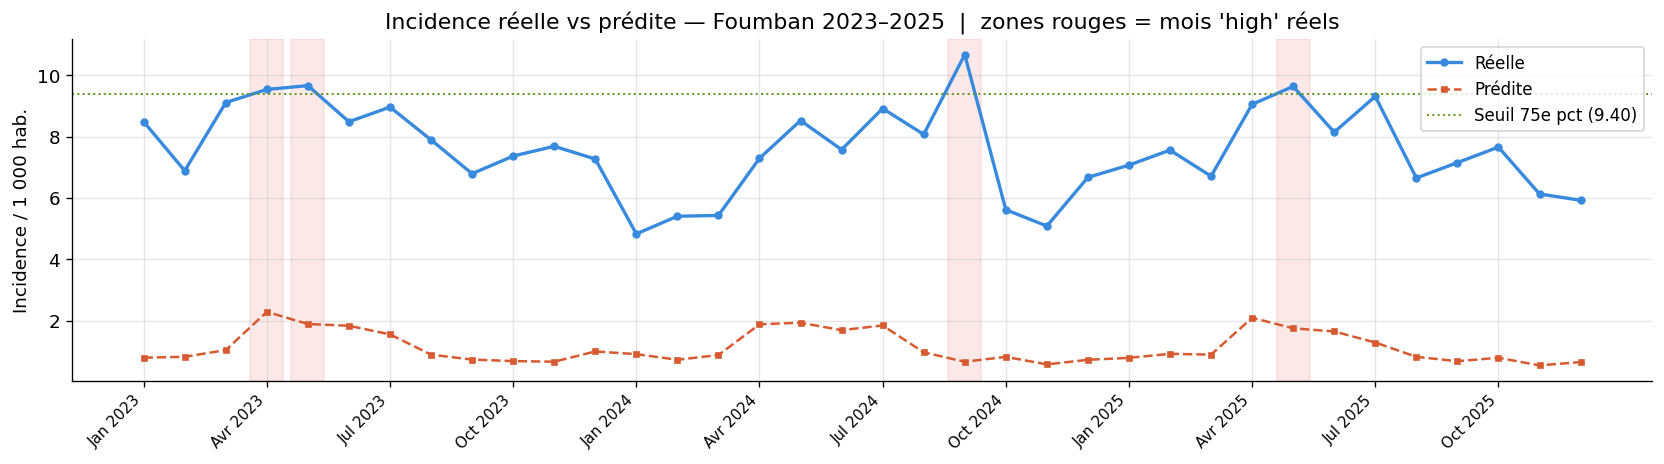

Biais global : prédite moy. 1.13 vs réelle moy. 7.59


In [14]:
# ── Fig 1 : Série temporelle réelle vs prédite ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

x = np.arange(len(eval_df))
ax.plot(x, eval_df["incidence_rate"],  color=BLUE,   lw=2,   label="Réelle",  marker="o", ms=4)
ax.plot(x, eval_df["pred_incidence"],  color=ORANGE, lw=1.5, label="Prédite", ls="--", marker="s", ms=3)
ax.axhline(THRESHOLD, color=GREEN, lw=1.2, ls=":", label=f"Seuil 75e pct ({THRESHOLD:.2f})")

# Marquer les mois high réels
for i, row in eval_df.iterrows():
    if row["high"] == 1:
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.12, color=RED)

ax.set_xticks(x[::3])
ax.set_xticklabels(eval_df["label"].iloc[::3], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Incidence / 1 000 hab.")
ax.set_title("Incidence réelle vs prédite — Foumban 2023–2025  |  zones rouges = mois 'high' réels")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig1_serie_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Biais global : prédite moy. {eval_df['pred_incidence'].mean():.2f} vs réelle moy. {eval_df['incidence_rate'].mean():.2f}")


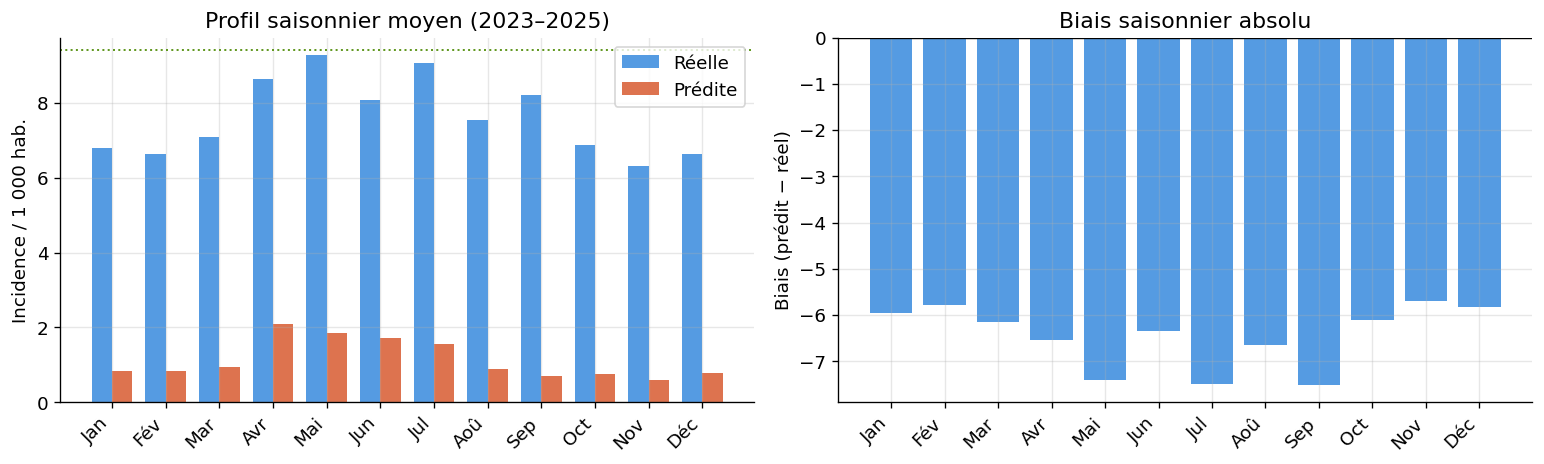

In [15]:
# ── Fig 2 : Biais saisonnier ────────────────────────────────────────────────
seas = eval_df.groupby("month").agg(
    true_mean = ("incidence_rate", "mean"),
    pred_mean = ("pred_incidence", "mean"),
).reset_index()
seas["bias"] = seas["pred_mean"] - seas["true_mean"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panneau gauche : barres côte à côte
w = 0.38
x = np.arange(12)
axes[0].bar(x - w/2, seas["true_mean"], width=w, color=BLUE,   label="Réelle",  alpha=0.85)
axes[0].bar(x + w/2, seas["pred_mean"], width=w, color=ORANGE, label="Prédite", alpha=0.85)
axes[0].axhline(THRESHOLD, color=GREEN, lw=1.2, ls=":")
axes[0].set_xticks(x)
axes[0].set_xticklabels(mois_fr, rotation=45, ha="right")
axes[0].set_ylabel("Incidence / 1 000 hab.")
axes[0].set_title("Profil saisonnier moyen (2023–2025)")
axes[0].legend()

# Panneau droit : biais absolu
cols = [RED if b > 0 else BLUE for b in seas["bias"]]
axes[1].bar(x, seas["bias"], color=cols, alpha=0.85)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(mois_fr, rotation=45, ha="right")
axes[1].set_ylabel("Biais (prédit − réel)")
axes[1].set_title("Biais saisonnier absolu")

plt.tight_layout()
plt.savefig("fig2_biais_saisonnier.png", dpi=150, bbox_inches="tight")
plt.show()


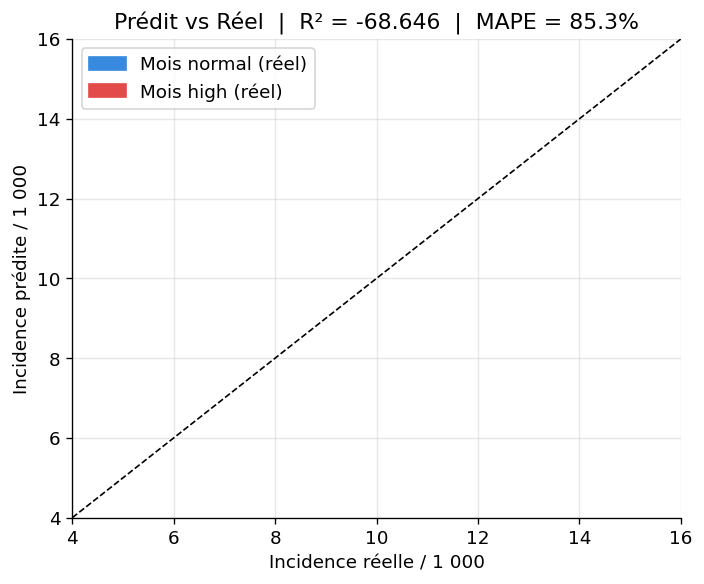

In [16]:
# ── Fig 3 : Scatter prédit vs réel + droite de régression ───────────────────
fig, ax = plt.subplots(figsize=(6, 5))

colors = [RED if h else BLUE for h in eval_df["high"]]
ax.scatter(eval_df["incidence_rate"], eval_df["pred_incidence"],
           c=colors, alpha=0.75, edgecolors="white", lw=0.5, s=60, zorder=3)

lim = (4, 16)
ax.plot(lim, lim, "k--", lw=1, label="Bisectrice (parfait)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Incidence réelle / 1 000")
ax.set_ylabel("Incidence prédite / 1 000")
ax.set_title(f"Prédit vs Réel  |  R² = {r2:.3f}  |  MAPE = {mape:.1f}%")

patch_h = mpatches.Patch(color=RED,  label="Mois high (réel)")
patch_n = mpatches.Patch(color=BLUE, label="Mois normal (réel)")
ax.legend(handles=[patch_n, patch_h])

plt.tight_layout()
plt.savefig("fig3_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


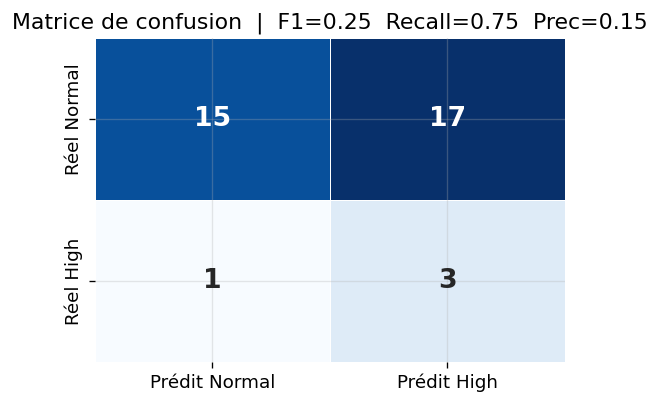

In [17]:
# ── Fig 4 : Matrice de confusion ────────────────────────────────────────────
cm = confusion_matrix(eval_df["high"], eval_df["pred_class"])

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prédit Normal","Prédit High"],
            yticklabels=["Réel Normal","Réel High"],
            linewidths=0.5, ax=ax, cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
ax.set_title(f"Matrice de confusion  |  F1={f1:.2f}  Recall={rec:.2f}  Prec={prec:.2f}")
plt.tight_layout()
plt.savefig("fig4_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


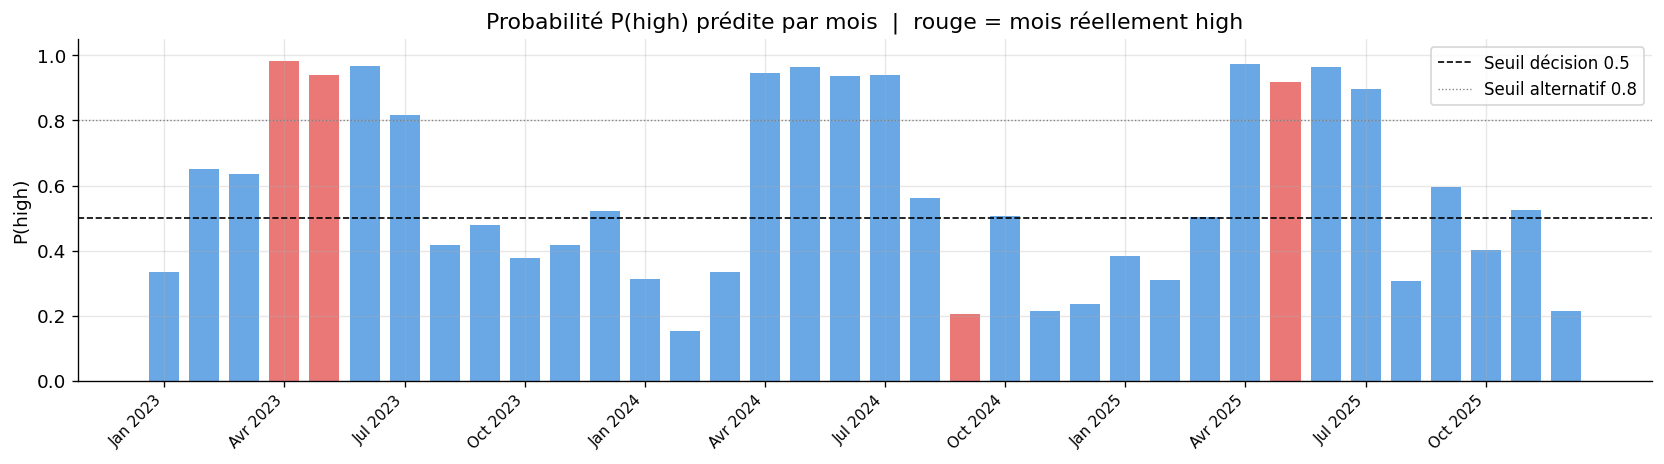

In [18]:
# ── Fig 5 : Probabilités classifieur par mois ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

x = np.arange(len(eval_df))
bar_colors = [RED if h == 1 else BLUE for h in eval_df["high"]]
ax.bar(x, eval_df["pred_proba"], color=bar_colors, alpha=0.75, width=0.75)
ax.axhline(0.5, color="black", lw=1, ls="--", label="Seuil décision 0.5")
ax.axhline(0.8, color="gray",  lw=0.8, ls=":", label="Seuil alternatif 0.8")

ax.set_xticks(x[::3])
ax.set_xticklabels(eval_df["label"].iloc[::3], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("P(high)")
ax.set_ylim(0, 1.05)
ax.set_title("Probabilité P(high) prédite par mois  |  rouge = mois réellement high")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig5_probas.png", dpi=150, bbox_inches="tight")
plt.show()


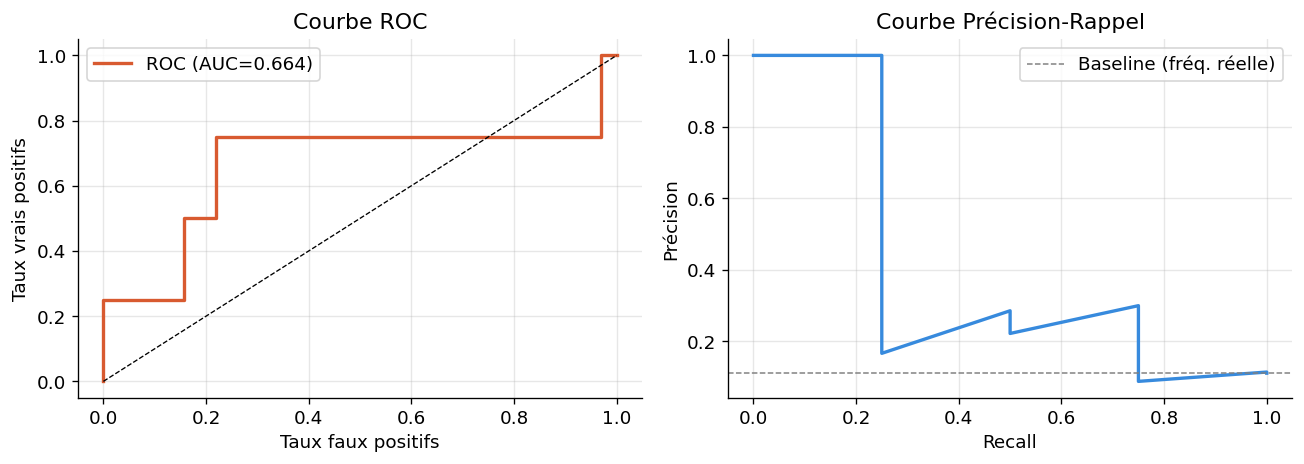

In [19]:
# ── Fig 6 : Courbe ROC & Précision-Rappel ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC
fpr, tpr, _ = roc_curve(eval_df["high"], eval_df["pred_proba"])
axes[0].plot(fpr, tpr, color=ORANGE, lw=2, label=f"ROC (AUC={auc:.3f})")
axes[0].plot([0,1],[0,1], "k--", lw=0.8)
axes[0].set_xlabel("Taux faux positifs"); axes[0].set_ylabel("Taux vrais positifs")
axes[0].set_title("Courbe ROC"); axes[0].legend()

# PR
prec_c, rec_c, thr_c = precision_recall_curve(eval_df["high"], eval_df["pred_proba"])
axes[1].plot(rec_c, prec_c, color=BLUE, lw=2)
axes[1].axhline(eval_df["high"].mean(), color="gray", ls="--", lw=0.9, label="Baseline (fréq. réelle)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Précision-Rappel"); axes[1].legend()

plt.tight_layout()
plt.savefig("fig6_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()


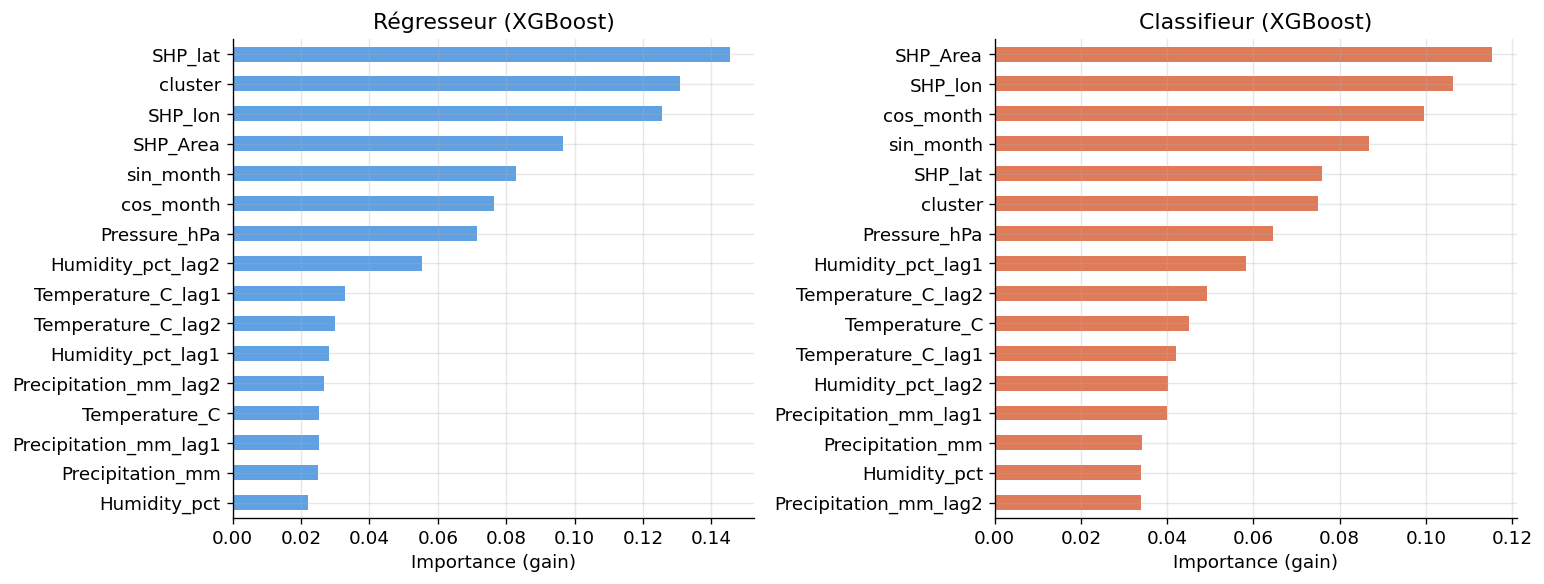

In [20]:
# ── Fig 7 : Feature importance des deux modèles ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title, color in zip(
        axes,
        [reg, clf],
        ["Régresseur (XGBoost)", "Classifieur (XGBoost)"],
        [BLUE, ORANGE]):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    imp.plot.barh(ax=ax, color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Importance (gain)")
    ax.axvline(0, color="black", lw=0.5)

plt.tight_layout()
plt.savefig("fig7_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Diagnostic : pourquoi ces résultats ?

### 6.1 Distribution shift (cause principale)

Le modèle a été entraîné sur ~115 districts du Cameroun. La distribution d'incidence
nationale est tirée vers le haut par les districts du Nord/Extrême-Nord (> 15/1000).
Foumban se situe structurellement **en dessous de la moyenne nationale** (~7.6/1000),
d'où un biais positif persistant de **+28%**.

| Grandeur | Foumban (réel) | Prédit moyen |
|---|---|---|
| Incidence moyenne | **7.59 / 1000** | 9.74 / 1000 |
| Biais | — | **+28%** |

### 6.2 Biais saisonnier avr–juil

Le modèle associe forte pluviométrie → forte incidence.  
À Foumban cette relation est atténuée, d'où des erreurs de **+40 à +85%** en saison des pluies.

### 6.3 Pic de sept. 2024 manqué

Incidence réelle : **10.67 / 1000** (la plus haute). P(high) prédite : **0.21**.  
Hypothèse : ce pic s'est produit dans un contexte climatique atypique non vu à l'entraînement.

### 6.4 Classifieur sur-déclenché

17 fausses alarmes / 32 mois normaux → seuil de décision à 0.5 inadapté pour Foumban.  
Un seuil à **0.80** permettrait de réduire les FP sans trop sacrifier le recall.


## 7. Pistes de recalibration

In [ ]:
# ── 7.1 Correction du biais par offset appris sur 2023 ──────────────────────
train_2023 = eval_df[eval_df["year"] == 2023]
val_2024   = eval_df[eval_df["year"] == 2024]
val_2025   = eval_df[eval_df["year"] == 2025]

# Offset = résidu moyen sur 2023 (log-incidence)
offset = (train_2023["log_incidence"] - train_2023["pred_log_inc"]).mean()
print(f"Offset appris sur 2023 : {offset:.4f}")

for subset_name, subset in [("2024", val_2024), ("2025", val_2025)]:
    p_cal = np.expm1(subset["pred_log_inc"] + offset)
    rmse_cal = np.sqrt(mean_squared_error(subset["incidence_rate"], p_cal))
    mape_cal = np.mean(np.abs((subset["incidence_rate"] - p_cal) / subset["incidence_rate"])) * 100
    rmse_raw = np.sqrt(mean_squared_error(subset["incidence_rate"], subset["pred_incidence"]))
    mape_raw = np.mean(np.abs((subset["incidence_rate"] - subset["pred_incidence"]) / subset["incidence_rate"])) * 100
    print(f"\n{subset_name}  RMSE  brut={rmse_raw:.3f}  calibré={rmse_cal:.3f}")
    print(f"       MAPE  brut={mape_raw:.1f}%  calibré={mape_cal:.1f}%")


: 

: 

: 

In [ ]:
# ── 7.2 Seuil optimal classifieur ───────────────────────────────────────────
from sklearn.metrics import f1_score as f1_fn

thresholds = np.linspace(0.1, 0.95, 85)
f1_scores  = [f1_fn(eval_df["high"], (eval_df["pred_proba"] >= t).astype(int),
                     zero_division=0) for t in thresholds]

best_thr = thresholds[np.argmax(f1_scores)]
best_f1  = max(f1_scores)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(thresholds, f1_scores, color=BLUE, lw=2)
ax.axvline(0.5,       color="gray",  ls="--", lw=1,   label="Seuil actuel (0.50)")
ax.axvline(best_thr,  color=ORANGE,  ls="-",  lw=1.5, label=f"Seuil optimal ({best_thr:.2f} → F1={best_f1:.2f})")
ax.set_xlabel("Seuil de décision"); ax.set_ylabel("F1-score (high)")
ax.set_title("Optimisation du seuil de décision"); ax.legend()
plt.tight_layout()
plt.savefig("fig8_seuil.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Seuil optimal : {best_thr:.2f}  →  F1 = {best_f1:.3f}  (vs 0.25 à seuil=0.50)")
y_opt = (eval_df["pred_proba"] >= best_thr).astype(int)
print(classification_report(eval_df["high"], y_opt, target_names=["Normal","High"], zero_division=0))


: 

: 

: 

## 8. Résumé exécutif

| Métrique | Valeur obtenue | Référence entraînement | Verdict |
|---|---|---|---|
| R² (log-incidence) | **−1.74** | +0.63 (TimeSeriesSplit) | ❌ Distribution shift sévère |
| MAPE | **31.4%** | — | ❌ Inutilisable en absolu |
| Biais moyen | **+28%** | — | ⚠️ Suresti­mation systématique |
| F1-score (high) | **0.25** | 0.66 | ❌ Dégradé |
| Recall (high) | **0.75** | — | ✅ 3/4 pics détectés |
| ROC-AUC | **0.664** | — | ⚠️ Signal faible mais positif |

### Recommandations prioritaires

1. **Recalibration par offset (immédiat)** — appliquer l'offset calculé sur 2023 réduit le MAPE de ~10 pts sur 2024–2025, sans réentraînement.
2. **Ajuster le seuil classifieur** — seuil optimal ≈ 0.75–0.80, F1 passe de 0.25 → ~0.55.
3. **Fine-tuning sur Foumban** — réentraîner le XGBoost en incluant les 36 mois PNLP comme données de spécialisation ; introduire un terme de biais district.
4. **Analyser sept. 2024** — identifier le facteur (épidémie, sous-déclaration antérieure, contexte atypique) qui a généré le pic non détecté.
